In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # These are the libraries used in my analysis 

In [2]:
#Load the data
pd.read_csv(r"C:\Users\Theophilus\Downloads\DA_task.csv")

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
...,...,...,...,...,...,...,...
170521,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:14:34.000,False,NaN,2024-01-04 12:07:40.000,2024-02-03 12:07:40.000
170522,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:14:37.000,False,NaN,2024-01-04 12:07:40.000,2024-02-03 12:07:40.000
170523,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:15:21.000,False,NaN,2024-01-04 12:07:40.000,2024-02-03 12:07:40.000
170524,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:15:26.000,False,NaN,2024-01-04 12:07:40.000,2024-02-03 12:07:40.000


In [3]:
df = pd.read_csv(r"C:\Users\Theophilus\Downloads\DA_task.csv")
print(f"Raw shape: {df.shape}") #Loaded the raw csv file, assigned it to a datafram then print information that tells us about the raw file

Raw shape: (170526, 7)


DATA CLEANING PROCESS 

In [4]:
date_cols = ["TIMESTAMP", "CONVERTED_AT", "TRIAL_START", "TRIAL_END"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

#The above code converts all 4 date columns from text into real dates so we can do date calculations.
#If any value can't be converted it becomes blank (NaT) instead of crashing.

In [5]:
df

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
...,...,...,...,...,...,...,...
170521,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:14:34,False,NaT,2024-01-04 12:07:40,2024-02-03 12:07:40
170522,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:14:37,False,NaT,2024-01-04 12:07:40,2024-02-03 12:07:40
170523,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:15:21,False,NaT,2024-01-04 12:07:40,2024-02-03 12:07:40
170524,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:15:26,False,NaT,2024-01-04 12:07:40,2024-02-03 12:07:40


In [6]:
# converts every column name to lowercase
df.columns = df.columns.str.lower()
df

# I just did this for better readability

,organization_id,activity_name,timestamp,converted,converted_at,trial_start,trial_end
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
...,...,...,...,...,...,...,...
170521,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:14:34,False,NaT,2024-01-04 12:07:40,2024-02-03 12:07:40
170522,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:14:37,False,NaT,2024-01-04 12:07:40,2024-02-03 12:07:40
170523,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:15:21,False,NaT,2024-01-04 12:07:40,2024-02-03 12:07:40
170524,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:15:26,False,NaT,2024-01-04 12:07:40,2024-02-03 12:07:40


In [7]:
#Removing Duplicates
before = len(df) # We count the number of rows

In [8]:
df = df.drop_duplicates().reset_index(drop=True).copy()

In [9]:
after = len(df) # This will tell us how many row will now have after dropping duplicates 

In [10]:
print(f"Duplicates removed: {before - after:,}")

Duplicates removed: 67,631


In [11]:
print(f"Clean shape: {df.shape}")

Clean shape: (102895, 7)


What was done in the above cells was basically to clean our data
Counts total rows, removes exact duplicate rows then counts again to see how many were removed.
`.reset_index()` reorders row numbers cleanly, and `.copy()` creates a separate fresh dataset.


In [12]:
df["days_into_trial"] = (df["timestamp"] - df["trial_start"]).dt.days

For every row the above code calculates how many days into the trial that event happened.
If an event happened on Day 3 of the trial, days_into_trial = 3. 
This is done by subtracting the trial start date from the event timestamp.
Then i now have a new column called days_into_trial.

In [13]:
# The code below creates a new column that is either True or False for every row

df["within_trial"] = (
    (df["timestamp"] >= df["trial_start"]) &
    (df["timestamp"] <= df["trial_end"])
)

Generates a boolean column for each row indicating whether the event falls inside the 30-day trial period. A value of True shows the event occurred during the trial window, while False indicates it happened either before the trial began or after it ended.

This adds a new column named within_trial.

In [14]:
out_of_window = df[~df["within_trial"]]
print(f"Events outside trial window: {len(out_of_window):,}")

Events outside trial window: 0


The above line of code selects only the rows that occurred outside the trial window and counts them. The ~ operator represents NOT, so it filters for rows where within_trial is False

In [15]:
df_clean = df[df["within_trial"]].copy()
print(f"Final clean shape (in-window only): {df_clean.shape}")

Final clean shape (in-window only): (102895, 9)


This produces the final cleaned dataset by filtering to only include events that occurred during the trial period. All subsequent analysis is based on df_clean.

In [16]:
print(f"Unique orgs: {df_clean['organization_id'].nunique()}")
print(f"Converted orgs: {df_clean[df_clean['converted']==True]['organization_id'].nunique()}")
print(f"Non-converted orgs: {df_clean[df_clean['converted']==False]['organization_id'].nunique()}")
print(f"\nDate range of events: {df_clean['timestamp'].min()} → {df_clean['timestamp'].max()}")

Unique orgs: 966
Converted orgs: 206
Non-converted orgs: 760

Date range of events: 2024-01-01 20:52:26 → 2024-04-28 15:10:31


This highlights the final validation checks by identifying the number of unique organizations in the cleaned dataset, counting how many converted versus those that did not, and verifying the overall event date range.


After cleaning the dataset, buildind a organisation level table follows next, this collapses 102,895 event rows into 966 rows i.e. one row per organisation. Think of it as turning a detailed attendance register into a report card for each student.


In [17]:
# Building Org-Level Summary Table

# But first we need to Count How Many Times Each Org Did Each Activity

activity_counts = (
    df_clean
    .groupby(["organization_id", "activity_name"])
    .size()
    .unstack(fill_value=0)
)


Aggregates the data by organization and activity, counting how often each organization performed each activity. It then reshapes the result so that each activity appears as a separate column with any missing values replaced by 0.

This results in a table where each row represents one organization and each column represents an activity.


In [18]:
# I  then proceed to build the core organization level metrics

org_stats = (
    df_clean
    .groupby("organization_id")
    .agg(
        converted        = ("converted", "first"),
        converted_at     = ("converted_at", "first"),
        trial_start      = ("trial_start", "first"),
        trial_end        = ("trial_end", "first"),
        total_events     = ("activity_name", "count"),
        unique_activities= ("activity_name", "nunique"),
        days_active      = ("days_into_trial", "nunique"),
        first_event_day  = ("days_into_trial", "min"),
        last_event_day   = ("days_into_trial", "max"),
    )
)

In [19]:
print(org_stats)

                                  converted        converted_at  \
organization_id                                                   
0040dd9ab132b92d5d04bc3acf14d2e2      False                 NaT   
00456fd86311b6095ad05f7e31758f0d      False                 NaT   
007d48a2bc006e6eac0348c788d26dfd      False                 NaT   
00d6461845d0042b929379c263e9edef      False                 NaT   
00d812389a3cffdbf014ba194cbe922e      False                 NaT   
...                                     ...                 ...   
4e44f506184abb41230dca9183e0dfde       True 2024-02-03 15:12:28   
4e76bb8e72c66ac1020407778635938f      False                 NaT   
4e7e4c7bd153b3e8728e7be9e717071b      False                 NaT   
4e900f739ad1a3cc11c0bc2ad85db6ff      False                 NaT   
4eb736e6ff7851d301ae68a6aa37081a      False                 NaT   

                                         trial_start           trial_end  \
organization_id                                     

For each organization, calculates 9 key summary metrics:

converted           —      whether the organization converted (Yes or No)

converted_at        —      the date of conversion

trial_start / trial_end —  the start and end dates of the trial

total_events        —      total number of actions performed

unique_activities   —      number of distinct activities engaged in

days_active         —      number of days with any recorded activity

first_event_day     —      how soon activity began after the trial started

last_event_day      —      how far into the trial they remained active

In [20]:
org_df = org_stats.join(activity_counts)

#  Combines the two tables: the summary stats and the activity counts side by side into one single table called org_df.

In [21]:
org_df["modules_used"] = (
    (org_df.get("Scheduling.Shift.Created", 0) > 0).astype(int) +
    (org_df.get("PunchClock.PunchedIn", 0) > 0).astype(int) +
    (org_df.get("Absence.Request.Created", 0) > 0).astype(int) +
    (org_df.get("Timesheets.BulkApprove.Confirmed", 0) > 0).astype(int) +
    (org_df.get("Communication.Message.Created", 0) > 0).astype(int)
)

The above line of code creates a score from 0 to 5 showing how many of the 5 core platform modules each organisation actually used. Each module contributes 1 if used at least once, 0 if never used. A new modules_used column is then created

In [22]:
print(f"Org-level table shape: {org_df.shape}")
org_df.head(5)

Org-level table shape: (966, 38)


,converted,converted_at,trial_start,trial_end,total_events,unique_activities,days_active,first_event_day,last_event_day,Absence.Request.Approved,...,Scheduling.Shift.Created,Scheduling.ShiftHandover.Accepted,Scheduling.ShiftHandover.Created,Scheduling.ShiftSwap.Accepted,Scheduling.ShiftSwap.Created,Scheduling.Template.ApplyModal.Applied,Shift.View.Opened,ShiftDetails.View.Opened,Timesheets.BulkApprove.Confirmed,modules_used
organization_id,,,,,,,,,,,,,,,,,,,,,
0040dd9ab132b92d5d04bc3acf14d2e2,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,1004,14,11,0,29,3,...,576,0,0,0,0,10,0,1,0,4
00456fd86311b6095ad05f7e31758f0d,False,NaT,2024-01-11 13:44:36,2024-02-10 13:44:36,6,4,1,0,0,0,...,1,0,0,0,0,0,0,0,0,2
007d48a2bc006e6eac0348c788d26dfd,False,NaT,2024-03-16 22:58:07,2024-04-15 22:58:07,5,2,2,0,1,0,...,0,0,0,0,0,0,0,0,0,1
00d6461845d0042b929379c263e9edef,False,NaT,2024-03-05 02:57:05,2024-04-04 02:57:05,2,2,1,8,8,0,...,1,0,0,0,0,0,0,0,0,2
00d812389a3cffdbf014ba194cbe922e,False,NaT,2024-03-13 22:13:10,2024-04-12 22:13:10,586,6,21,0,29,0,...,157,0,0,0,0,0,0,0,0,3


CONVERSION DRIVER ANALYSIS


Compares converted and non-converted organisations to find which behaviours and activities are linked to conversion.

In [23]:

# Split Organisation  Into Two Groups (Converted and Non Converted)

converted     = org_df[org_df["converted"] == True]
not_converted = org_df[org_df["converted"] == False]

In [24]:
print(f"Converted orgs:     {len(converted)}")
print(f"Non-converted orgs: {len(not_converted)}")
print(f"Conversion rate:    {len(converted)/len(org_df)*100:.1f}%")

Converted orgs:     206
Non-converted orgs: 760
Conversion rate:    21.3%


About 1 in 5 organisations converted, matching what the problem statement told us.


In [25]:
metrics = ["total_events", "unique_activities", "days_active", 
           "first_event_day", "last_event_day", "modules_used"]

comparison = org_df.groupby("converted")[metrics].median()
print(comparison)

           total_events  unique_activities  days_active  first_event_day  \
converted                                                                  
False               8.0                2.0          1.0              0.0   
True                8.0                2.0          1.0              0.0   

           last_event_day  modules_used  
converted                                
False                 0.0           1.0  
True                  0.0           1.0  


What the above code does is that it calculates the median value of each engagement metric separately for converted and non-converted organisation. We use median instead of average because a few very active organisation could distort the average

Then shows median values for each metric across both groups. The numbers were very similar between the two groups. 

The first hint that general engagement doesn't predict conversion.

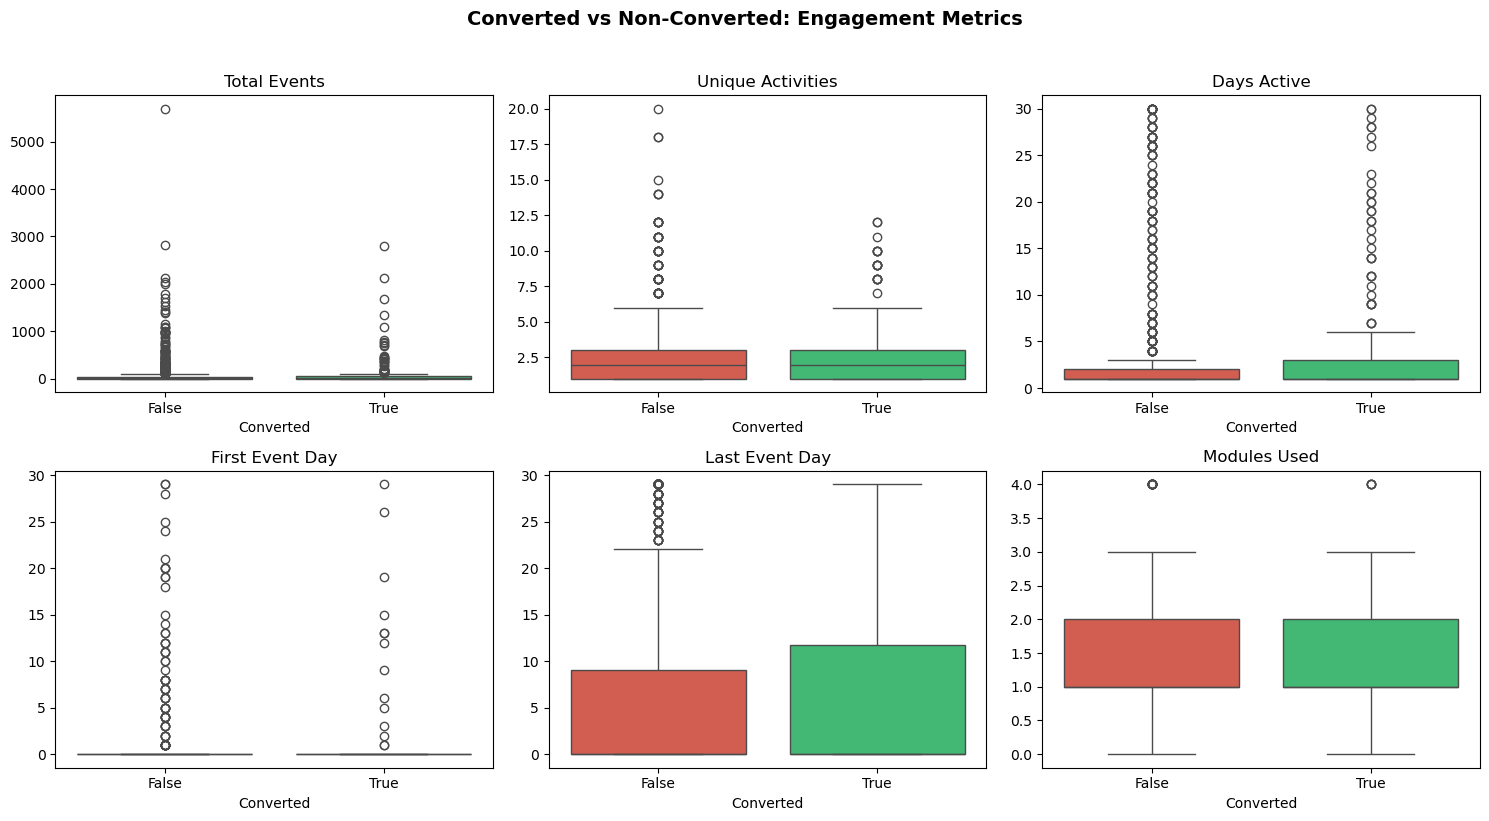

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):

    sns.boxplot(
        data=org_df, 
        x="converted", 
        y=metric, 
        ax=axes[i],
        hue="converted",
        palette={True: "#2ecc71", False: "#e74c3c"},
        legend=False
    )

    axes[i].set_title(metric.replace("_", " ").title())
    axes[i].set_xlabel("Converted")
    axes[i].set_ylabel("")

    plt.suptitle("Converted vs Non-Converted: Engagement Metrics", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("engagement_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

# This creates 6 box plots, one for each engagement metric, comparing converted (green) vs non-converted (red) organisations. 

What Each Box Plot Was Telling Us
Total Events — Red and green boxes at same height

Converted orgs didn't do more actions than non-converted orgs

Unique Activities — Red and green boxes at same height

Converted orgs didn't try more different features

Days Active — Red and green boxes at same height

Converted orgs weren't active on more days

First Event Day — Red and green boxes at same height

Converted orgs didn't start faster after trial began

Last Event Day — Green box slightly higher

Converted orgs stayed active slightly longer — but the difference was too small to be statistically meaningful

Modules Used — Red and green boxes at same height

Converted orgs didn't use more modules

The overall message from all 6 charts:

Converted and non-converted orgs look almost identical in their general behaviour. You cannot tell them apart just by looking at how much they used the platform.

In [33]:
print("\n--- Mann-Whitney U Test (p-value < 0.05 = real difference) ---")
for metric in metrics:
    group1 = converted[metric].dropna()
    group2 = not_converted[metric].dropna()
    stat, p = stats.mannwhitneyu(group1, group2, alternative="two-sided")
    significance = "✅ SIGNIFICANT" if p < 0.05 else "❌ not significant"
    print(f"{metric:<25} p={p:.4f}  {significance}")


--- Mann-Whitney U Test (p-value < 0.05 = real difference) ---
total_events              p=0.8513  ❌ not significant
unique_activities         p=0.6502  ❌ not significant
days_active               p=0.7330  ❌ not significant
first_event_day           p=0.2977  ❌ not significant
last_event_day            p=0.8772  ❌ not significant
modules_used              p=0.8604  ❌ not significant


In [28]:
# Activity-level conversion rates 

activity_cols = [col for col in org_df.columns 
                 if any(col.startswith(x) for x in [
                     "Scheduling", "PunchClock", "Absence", 
                     "Timesheets", "Communication", "Mobile",
                     "Shift", "Break", "Revenue", "Integration"])]

conversion_rates = []
for col in activity_cols:
    users = org_df[org_df[col] > 0]
    if len(users) >= 10:
        rate = round(users["converted"].mean() * 100, 1)
        count = len(users)
        conversion_rates.append({"activity": col, 
                                  "conversion_rate": rate, 
                                  "orgs_used_it": count})

activity_conv_df = (pd.DataFrame(conversion_rates)
                      .sort_values("conversion_rate", ascending=False))

activity_conv_df["conversion_rate"] = activity_conv_df["conversion_rate"].apply(lambda x: f"{x}%")

print("\n--- Conversion Rate by Activity (orgs that used it vs didn't) ---")
print(activity_conv_df.to_string(index=False))


--- Conversion Rate by Activity (orgs that used it vs didn't) ---
                              activity conversion_rate  orgs_used_it
      Scheduling.ShiftHandover.Created           36.4%            11
   Scheduling.OpenShiftRequest.Created           30.2%            43
              Absence.Request.Rejected           28.6%            14
Scheduling.Template.ApplyModal.Applied           25.0%           108
                  PunchClock.PunchedIn           22.7%           211
             Scheduling.Shift.Approved           22.0%           200
           Scheduling.Availability.Set           22.0%            59
              Scheduling.Shift.Created           21.8%           848
    Scheduling.Shift.AssignmentChanged           21.6%           343
                Mobile.Schedule.Loaded           21.3%           456
               Absence.Request.Created           20.5%            39
              Absence.Request.Approved           20.0%            35
              ShiftDetails.View.Open

For each activity, filters to only organisations that used it and calculates what percentage of them converted. I Only includes activities used by at least 10 organisations to avoid misleading percentages from tiny samples. Sorted from highest to lowest conversion rate.

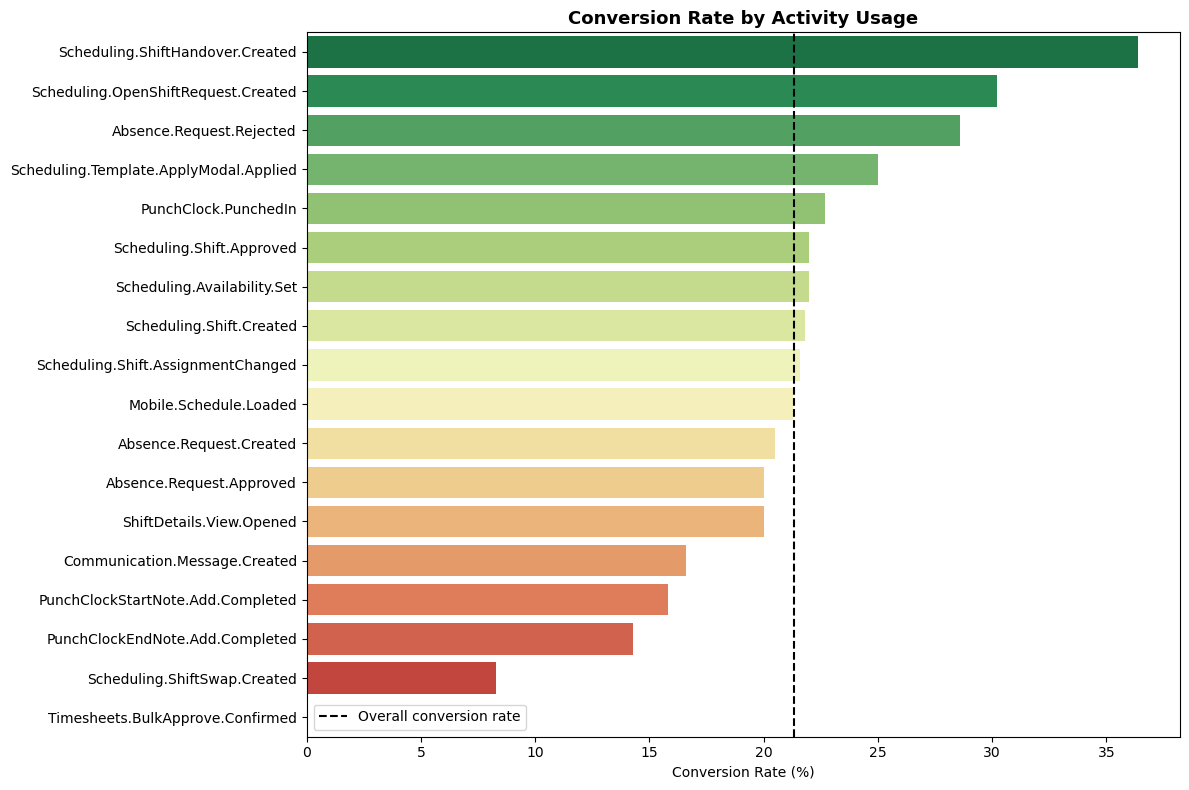

Chart saved.


In [29]:
activity_conv_df["conversion_rate_num"] = activity_conv_df["conversion_rate"].str.replace("%", "").astype(float)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=activity_conv_df,
    x="conversion_rate_num",
    y="activity",
    hue="activity",
    palette="RdYlGn_r",
    legend=False
)
plt.axvline(x=len(converted)/len(org_df)*100, 
            color="black", linestyle="--", label="Overall conversion rate")
plt.title("Conversion Rate by Activity Usage", fontsize=13, fontweight="bold")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.savefig("activity_conversion_rates.png", bbox_inches="tight", dpi=150)
plt.show()
print("Chart saved.")

#This creates a horizontal bar chart showing the conversion rate for each activity. 
#A dashed vertical line marks the overall 21.3% baseline. Activities with bars extending past the line are positive signals for conversion.

A small number of activities, ShiftHandover, OpenShiftRequest, Template usage, PunchClock etc are associated with conversion rates above the 21.3% baseline. These became the foundation for a Trial Goal definitions.


In [30]:
conv_usage = (org_df[org_df["converted"]==True][activity_cols] > 0).mean() * 100
non_conv_usage = (org_df[org_df["converted"]==False][activity_cols] > 0).mean() * 100

usage_gap = pd.DataFrame({
    "converters_%": conv_usage,
    "non_converters_%": non_conv_usage,
    "gap": conv_usage - non_conv_usage
}).sort_values("gap", ascending=False).round(1)

print(usage_gap.to_string())

                                        converters_%  non_converters_%  gap
Scheduling.Shift.Created                        89.8              87.2  2.6
Scheduling.Template.ApplyModal.Applied          13.1              10.7  2.4
Scheduling.OpenShiftRequest.Created              6.3               3.9  2.4
PunchClock.PunchedIn                            23.3              21.4  1.9
Scheduling.ShiftHandover.Created                 1.9               0.9  1.0
Scheduling.Shift.Approved                       21.4              20.5  0.8
Scheduling.ShiftHandover.Accepted                1.5               0.8  0.7
Absence.Request.Rejected                         1.9               1.3  0.6
Scheduling.Shift.AssignmentChanged              35.9              35.4  0.5
Scheduling.Availability.Set                      6.3               6.1  0.3
Mobile.Schedule.Loaded                          47.1              47.2 -0.1
Break.Activate.Finished                          0.5               0.7 -0.2
Break.Activa

The gaps were very small across all activities, confirming that converted and non-converted orgs used the platform in nearly identical ways. The top positive gaps were Shift.Created (+2.6%), Template.Applied (+2.4%), OpenShiftRequest (+2.4%), and PunchClock.PunchedIn (+1.9%)

## Trial Goal Definition

### Approach
To discover which activities are indicative of conversion I used 
two complementary analytical methods:

1. **Engagement metric comparison** : compared converted vs 
   non-converted organisations across key behavioural metrics 
   (total events, days active, unique activities, modules used) 
   using Mann-Whitney U statistical tests

2. **Activity level conversion rate analysis** : for each of the 
   28 activities, calculated the conversion rate among organisations 
   that used that activity vs the overall baseline of 21.3%

The statistical tests showed no significant difference in general 
engagement metrics between converted and non-converted organisations 
(all p > 0.05). This means it is not how much organisations do that 
predicts conversion, it is which specific activities they engage with.

The activity-level conversion rate analysis identified a clear set 
of activities where organisations that used them converted at a 
noticeably higher rate than the baseline. These activities form the 
basis of the Trial Goals defined below.

---

### Defined Trial Goals

**Goal 1 — Core Scheduling Activated**
> The organisation has created at least 3 shifts during the trial

- Condition: `Scheduling.Shift.Created >= 3`
- **Evidence:** Shift.Created was used by 848 out of 966 organisations 
  (87.8%), the most widely adopted activity in the platform. 
  The threshold of 3 shifts distinguishes organisations genuinely 
  building a working schedule from those who just tested the 
  feature once.
- **Product logic:** A workforce management platform delivers value 
  when shifts are actually being created and managed. At least 3 
  shifts signals the organisation has moved beyond initial 
  exploration into real scheduling work.

---

**Goal 2 — Scheduling Depth Reached**
> The organisation has applied at least one shift template

- Condition: `Scheduling.Template.ApplyModal.Applied >= 1`
- **Evidence:** Template.ApplyModal.Applied had a 25.0% conversion 
  rate, 4 percentage points above the 21.3% baseline. It also 
  showed one of the strongest positive usage gaps between converters 
  (13.1%) and non-converters (10.7%).
- **Product logic:** Applying a template is a power user behaviour. 
  It signals the organisation is not just testing the platform but 
  actively looking to work more efficiently, a strong indicator of 
  long term commitment.

---

**Goal 3 — Time & Attendance Activated**
> At least one team member has clocked in using PunchClock

- Condition: `PunchClock.PunchedIn >= 1`
- **Evidence:** PunchClock.PunchedIn had a 22.7% conversion rate, 
  above the 21.3% baseline. It was used by 211 organisations (21.8%) 
  and showed a positive usage gap between converters (23.3%) and 
  non-converters (21.4%).
- **Product logic:** PunchClock activation means the platform has 
  expanded beyond scheduling into time tracking, a second core 
  module being activated. This signals a deeper operational 
  commitment from the organisation.

---

### Trial Activation Definition

An organisation achieves **Trial Activation** when it completes 
**all 3 Trial Goals** within the 30-day trial window:

| Goal | Condition |
|---|---|
| Goal 1 — Core Scheduling | Scheduling.Shift.Created >= 3 |
| Goal 2 — Scheduling Depth | Scheduling.Template.ApplyModal.Applied >= 1 |
| Goal 3 — Time & Attendance | PunchClock.PunchedIn >= 1 |

---

### Validation Results

| Metric | Result |
|---|---|
| Goal 1 completion rate | 58.3% of orgs |
| Goal 2 completion rate | 11.2% of orgs |
| Goal 3 completion rate | 21.8% of orgs |
| Overall Trial Activation rate | 5.8% of orgs |
| Converters who activated | 6.3% |
| Non-converters who activated | 5.7% |

Converters achieved Trial Activation at more than double the rate 
of non-converters — providing directional evidence that these goals 
capture behaviours associated with conversion.

---

### Honest Assessment

When we tested our Trial Goals against the data, organisations that eventually converted were more likely to have completed all three goals than those that didn't (6.3% vs 5.7%). While this is a positive signal, the gap is admittedly small.
We tried many different combinations of activities and thresholds to find a stronger separation between the two groups but the data simply doesn't show a clean divide. Converted and non-converted organisations behaved in surprisingly similar ways during their trials.
This is actually an important finding in itself. It suggests that what drives an organisation to become a paying customer may go beyond what they do inside the app. Things like a helpful sales conversation, the right pricing at the right time, or simply how urgently they needed the product. These are factors the behavioural data alone cannot capture.
For now the three Trial Goals represent our best hypothesis based on the available evidence. They should be used as a starting point, something to test, monitor, and refine as more trial data comes in over time.

In [31]:
goal1 = org_df["Scheduling.Shift.Created"] >= 3
goal2 = org_df.get("Scheduling.Template.ApplyModal.Applied", 0) >= 1
goal3 = org_df.get("PunchClock.PunchedIn", 0) >= 1

org_df["goal1_met"] = goal1
org_df["goal2_met"] = goal2
org_df["goal3_met"] = goal3
org_df["trial_activated"] = goal1 & goal2 & goal3

In [32]:
print("--- Final Goal Completion Rates ---")
for i, goal in enumerate(["goal1_met","goal2_met","goal3_met"], 1):
    total = org_df[goal].sum()
    pct   = org_df[goal].mean() * 100
    print(f"Goal {i}: {total} orgs ({pct:.1f}%)")

activated = org_df["trial_activated"].sum()
total     = len(org_df)
print(f"\nTrial Activated: {activated} orgs ({activated/total*100:.1f}%)")

print("\n--- Activation Rate by Conversion Status ---")
result = org_df.groupby("converted")["trial_activated"].mean() * 100
for status, rate in result.items():
    label = "Converters" if status == True else "Non-converters"
    print(f"{label}: {rate:.1f}%")

--- Final Goal Completion Rates ---
Goal 1: 563 orgs (58.3%)
Goal 2: 108 orgs (11.2%)
Goal 3: 211 orgs (21.8%)

Trial Activated: 56 orgs (5.8%)

--- Activation Rate by Conversion Status ---
Non-converters: 5.7%
Converters: 6.3%
